<div dir=ltr align=center>

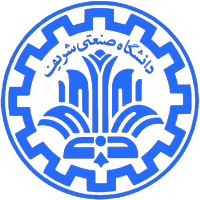

<br>
<font>
<div dir=ltr align=center>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Artificial Intelligence <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Arash Marioriyad<br>
    Spring 2026<br>
<font color=3C99D size=5>
    Practical HomeWork 3<br>
    HMM on DNA<br>
<font color=696880 size=4>
    Kimia Rezaei

`Full Name: Mohsen Salah`

`Student ID: 403106238`

# HMM Assignment

 –Sequence Modeling with Hidden Markov Models (HMM)

## Part 1: HMM Models


Introduce the concept of Hidden Markov Models (HMMs) and their applications in sequence modeling.

### -What is an HMM?
A Hidden Markov Model is a statistical model that represents systems with:
1. **Hidden states** – not directly observable (e.g., phonemes, weather conditions, gene regions).
2. **Observable outputs** – emitted signals or features (e.g., audio features, weather observations).

### - Key Components of an HMM:
- **States (Z)**: Hidden variables (e.g., phonemes in speech recognition).
- **Observations (X)**: Observable features (e.g., MFCCs from audio).
- **Initial Probabilities (π)**: Probability of starting in a particular state.
- **Transition Probabilities (A)**: Probability of moving from one state to another.
- **Emission Probabilities (B)**: Probability of observing a value given a state.

### -HMM Process Overview:
At each time step `t`, the system:
1. Transitions from one state to another using **transition probability A**
2. Emits an observation using **emission probability B**

### - Why Use HMMs?
HMMs are useful for modeling sequential data where the underlying structure is hidden but can be inferred from observations.

#### Example Applications:
- **Speech Recognition** – Infer phonemes from audio features
- **Natural Language Processing** – POS tagging, named entity recognition
- **Bioinformatics** – Identify coding vs. non-coding DNA regions
- **Finance** – Regime detection in time series

---

 In this part, we will:
- Work with dna datasets
- Extract HMM parameters from data
- Implement HMM algorithms from scratch
- Visualize results to understand hidden sequences



## Part 2: Extract HMM Parameters from DNA Dataset ##

In this section, you'll use a labeled DNA dataset to extract the core parameters of a Hidden Markov Model:
- **Initial Probabilities** – likelihood of starting in a specific hidden state
- **Transition Matrix** – probabilities of switching from one hidden state to another
- **Emission Matrix** – probabilities of emitting a specific observation given the hidden state

We are given labeled sequences of DNA nucleotides with associated hidden states (`Coding` or `NonCoding`). Using this, we can compute the HMM parameters as follows:


####  Initial Probabilities (π)
- For each sequence, check the **first position** (Position == 1).
- Count how many times each hidden state appears at the start.
- Normalize the counts to get the starting probability distribution.

####  Transition Probabilities (A)
- For each sequence, look at every **pair of consecutive states** (from Position _t_ to _t+1_).
- Count how often each transition occurs (e.g., Coding → Coding, Coding → NonCoding).
- For each state, normalize its outgoing transition counts to sum to 1.

####  Emission Probabilities (B)
- For each state, count how frequently it emits each nucleotide (A, C, G, T).
- Normalize these counts within each state.

This method is based on **maximum likelihood estimation(MLE)** using frequency counts, which is valid because we have access to the true hidden states.
These parameters will be used in later for performing inference (Forward/Viterbi).



### Load the Dataset ###

In [35]:
# Load the synthetic DNA dataset
# It contains Sequence_ID, Position, Nucleotide (A/C/G/T), and State (Coding/NonCoding).

import pandas as pd
import numpy as np
#TODO
# Load dataset
# Preview the data

df = pd.read_csv("dna_dataset.csv")
df.head()

,Sequence_ID,Position,Nucleotide,State
0,1,1,A,Coding
1,1,2,G,NonCoding
2,1,3,G,Coding
3,1,4,A,NonCoding
4,1,5,T,Coding


### Identify Unique States and Observations ###

In [36]:
# Get the unique hidden states and observable symbols (nucleotides).
# This helps us define our state and observation spaces for the HMM.
# TODO:
# states =
# observations =

states = df["State"].unique().tolist()
observations = df["Nucleotide"].unique().tolist()

print(f"States: {states}")
print(f"Observatinos: {observations}")

States: ['Coding', 'NonCoding']
Observatinos: ['A', 'G', 'T', 'C']


### Estimate Initial Probabilities (π) ###

In [37]:
# Compute the probability of starting in each state.
# This is based on the first position of each sequence in the dataset.

# TODO: Count how often each state appears as the first state in a sequence

initial_df = df[df["Position"] == 1]
initial_states = initial_df["State"].unique().tolist()

initial_probs = {}
count_total = 0

for state in states:
    initial_probs[state] = int(initial_df["State"].value_counts()[state])
    count_total += initial_probs[state]

for k,v in initial_probs.items():
    if count_total > 0:
        initial_probs[k] = v / count_total
    else:
        initial_probs[k] = 0.0

print("Initial Probabilities (π):", initial_probs)

Initial Probabilities (π): {'Coding': 0.49, 'NonCoding': 0.51}


### Estimate Transition Probabilities (A) ###

In [38]:
# Compute the probability of transitioning from one hidden state to another.
# Based on how states change within each sequence.

# TODO: Count transitions between states

df["Next_State"] = df.groupby("Sequence_ID")["State"].shift(-1)

valid_transitions = df.dropna(subset=["Next_State"])

transition_matrix = pd.crosstab(valid_transitions["State"], valid_transitions["Next_State"], normalize="index")
transition_probs = transition_matrix.to_dict(orient="index")

print("Transition Probabilities (A):")
for from_state, to_probs in transition_probs.items():
    print(from_state, "→", to_probs)

Transition Probabilities (A):
Coding → {'Coding': 0.4450775142440705, 'NonCoding': 0.5549224857559295}
NonCoding → {'Coding': 0.5823615160349854, 'NonCoding': 0.4176384839650146}


### Estimate Emission Probabilities (B) ###

In [39]:
# Compute the probability of emitting a given nucleotide from each hidden state.
# Based on how frequently each nucleotide appears for a given state.

# TODO: Count emissions for each (state, observation) pair

emission_matrix = pd.crosstab(df["State"], df["Nucleotide"], normalize="index")
emission_probs = emission_matrix.to_dict(orient="index")

print("Emission Probabilities (B):")
for state, probs in emission_probs.items():
    print(state, "→", probs)

Emission Probabilities (B):
Coding → {'A': 0.2556261195245074, 'C': 0.2506757857026543, 'G': 0.24950333821853118, 'T': 0.2441947565543071}
NonCoding → {'A': 0.35343915343915344, 'C': 0.14794333504010923, 'G': 0.1501962792285373, 'T': 0.3484212322922}


## Part 3: Forward Algorithm (Filtering with Elapse Time + Observation)

The **Forward Algorithm** helps us compute the probability of an observation sequence in a Hidden Markov Model (HMM). It also gives us the belief about the system's hidden state at each time step.

To do this, it recursively applies two updates at each time step `t`:


###  Step 1: Elapse Time (Prediction)
Predict the probability of being in each hidden state at time `t`, before seeing the new observation:

$$
P(x_t | e_{1:t-1}) = \sum_{x_{t-1}} P(x_t | x_{t-1}) \cdot P(x_{t-1} | e_{1:t-1})
$$

This uses the **transition probabilities (A)** and previous beliefs.


###  Step 2: Observation Update (Bayesian Update)
Once we see the new observation `e_t`, we update our beliefs:

$$
P(x_t | e_{1:t}) \propto P(e_t | x_t) \cdot P(x_t | e_{1:t-1})
$$

This uses the **emission probabilities (B)** and normalizes the result.


### Final Result:
- We maintain a belief `α_t(x)` for each state `x` at every time step.
- We can compute the total probability of the sequence by summing the final α values.



In [40]:
def elapse_time(prior, transition_probs, states):
    """
    Predicts the belief at time t using the belief at time t-1 and transition matrix A.

    Parameters:
    - prior: dict of P(state at t-1 | evidence up to t-1)
    - transition_probs: dict of dicts P(to_state | from_state)
    - states: list of possible states

    Returns:
    - prediction: dict of P(state at t | evidence up to t-1)
    """
    
    output = {}
    
    for s in states:
        output[s] = 0.0
        for s_prior in states:
            output[s] += (transition_probs[s_prior][s]) * (prior[s_prior])
            
    return output


In [41]:
def observe(predicted, observation, emission_probs, states):
    """
    Updates the belief at time t after seeing observation e_t, using emission matrix B.

    Parameters:
    - predicted: dict of P(state at t | evidence up to t-1)
    - observation: the observed symbol at time t (e.g., 'A')
    - emission_probs: dict of dicts P(obs | state)
    - states: list of possible states

    Returns:
    - updated: dict of P(state at t | evidence up to t)
    """

    output = {}

    for s in states:
        output[s] = emission_probs[s][observation] * predicted[s]

    total = sum(output.values())
    normalized_dict = {k: v / total for k, v in output.items()}
    
    return normalized_dict

In [42]:
def forward_algorithm(observation_sequence, states, start_probs, transition_probs, emission_probs):
    """
    Runs the full forward algorithm over an observation sequence.

    Parameters:
    - observation_sequence: list of observations (e.g., ['A', 'C', 'T', ...])
    - states: list of hidden states
    - start_probs: initial state distribution (π)
    - transition_probs: transition matrix A
    - emission_probs: emission matrix B

    Returns:
    - alpha_list: list of belief dicts (α_t) over time
    - sequence_prob: total probability of the full observation sequence
    """

    alpha_vals = []
    sequence_prob = 1.0

    c_1 = sum(emission_probs[s][observation_sequence[0]] * start_probs[s] for s in states)
    alpha_vals.append(observe(start_probs, observation_sequence[0], emission_probs, states))

    sequence_prob *= c_1

    for i in range(1, len(observation_sequence)):
        observation = observation_sequence[i]
        prediction = elapse_time(alpha_vals[i - 1], transition_probs, states)

        c_t = sum(emission_probs[s][observation] * prediction[s] for s in states)
        alpha_vals.append(observe(prediction, observation, emission_probs, states))
        sequence_prob *= c_t

    return alpha_vals, sequence_prob

In [43]:
# Small test case
test_sequence = ['A','C','C','T','T','T','A','G']

# Run forward algorithm
alpha_vals, prob = forward_algorithm(
    test_sequence,
    states,
    initial_probs,
    transition_probs,
    emission_probs
)

print(f"\nTotal probability of sequence {test_sequence}: {prob:.6f}")
print("\nBelief at final time step:")
for state, p in alpha_vals[-1].items():
    print(f"P({state}) = {p:.4f}")



Total probability of sequence ['A', 'C', 'C', 'T', 'T', 'T', 'A', 'G']: 0.000019

Belief at final time step:
P(Coding) = 0.6443
P(NonCoding) = 0.3557
